# Algoritmo de Aprendizaje por Refuerzo Profundo para la Gestión del TI

Escenario 3

Instalación e importación de librerias

In [3]:
!pip install gym pandas numpy keras tensorflow==2.10.0

Defaulting to user installation because normal site-packages is not writeable
  Using cached gym-0.26.2.tar.gz (721 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)


ERROR: Could not find a version that satisfies the requirement tensorflow==2.10.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0, 2.22.0rc0)

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.10.0


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from collections import deque
import random
import gym
from gym import spaces
import time
import matplotlib.pyplot as plt
import gc

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Cargar el dataset desde un archivo CSV
data = pd.read_csv('data/network_metric.csv')

# Parámetros de red
X = data[['num_segments', 'congestion_index' ]]

# División de los datos
X_train, X_test = train_test_split(X, test_size=0.30, random_state=42)

scaler = MinMaxScaler()
scaler.fit(X_train)

# Transformación de los datos
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Definición del entorno

In [ ]:
class TactileInternetEnv(gym.Env):
    def __init__(self, data):
        super(TactileInternetEnv, self).__init__()
        self.data = np.array(data, dtype=np.float32)
        self.current_step = 0
        self.state = None
        self.packets_sent = 0
        self.packets_lost = 0
        self.packets_delayed = 0

        # Parámetros de codificación RLNC (Random Linear Network Coding)
        self.coefficients = 3
        self.generation_size = 3 

        # Rango de normalización para cada parámetro
        self.num_segments_range = (1, 10)  # Número de segmentos (1 a 10)
        self.cong_index_range = (0, 1) 
        
        # Definición del espacio de acción y el espacio de observación
        self.action_space = spaces.Discrete(5)  # Tres acciones: aumentar, mantener, reducir
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(data.shape[1],), dtype=np.float32)
        self.reset()

    def reset(self):
        self.current_step = 0
        self.received_packets = []     
        self.decoded = False
        self.state = self.data[self.current_step]
        return self.state

    def desnormalize(self, value, value_range):
        return (value_range[0] + value * (value_range[1] - value_range[0]))

    def rlnc_encode(self, data, num_coefficients): # Codifica los datos usando RLNC
        coefficients = np.random.rand(num_coefficients)
        coefficients = coefficients / np.sum(coefficients)  
        encoded_packet = np.sum([c * d for c, d in zip(coefficients, data)], axis=0)
        return coefficients, encoded_packet

    def rlnc_decode(self):
        if len(self.received_packets) < self.generation_size:
            return False
        try:
            A = []
            b = []
            for coeffs, packet in self.received_packets[:self.generation_size]:
                A.append(coeffs)
                b.append(packet[0])
            # Resolver sistema lineal
            A = np.array(A)
            b = np.array(b)
            decoded = np.linalg.solve(A, b)
            return True
        except np.linalg.LinAlgError:
            return False
        
    def simulate_lost_packet(self, cong_index, rate_bd):
        # Simula la pérdida de paquetes
        self.packets_sent += 1
        probability_loss = 0.8  
        if probability_loss < random.random() and cong_index > rate_bd :
            self.packets_lost += 1
            return False
        return True

    def simulate_packet_transfer(self, state, num_segments):
        # Simula el envío de paquetes codificados y calcula las métricas de red
        num_segments, cong_index = int(num_segments), state[1]
        packet_size = 1500  
        packet_size_bits = packet_size * 8 
        bandwidth = 100
        bandwidth_bps = bandwidth * 1e6 
        error_rate = 0.1 # 10%
        tpD = 0.001
        latency = 0.0
    
        start = time.time()
        original_data = [np.random.rand(10) for _ in range(self.generation_size)]
        
        # Codificar con RLNC
        encoded_packets = []
        for _ in range(num_segments):
            coeffs, encoded = self.rlnc_encode(original_data, self.coefficients)
            encoded_packets.append((coeffs, encoded))

        rate_bd = ( bandwidth/num_segments) / 100
        
        # Simular envío y recepción
        for packet in encoded_packets:
            # Simular la pérdida del paquete
            packet_sent = self.simulate_lost_packet(cong_index, rate_bd)
            if packet_sent:  
                self.received_packets.append(packet)

        # Decodificar
        self.decoded = self.rlnc_decode()

        if packet_sent: 
            latency = time.time() - start + tpD  
        else:
            latency = time.time() - start + tpD * 2  # Castigo por retransmisión 
            self.packets_sent += 1

        if latency > (tpD + tpD*0.1): 
            self.packets_delayed += 1    # Paquetes demorados
            
        # Goodput (datos útiles entregados por segundo)
        goodput_bps =  packet_size_bits / latency if latency > 0 else 0
        goodput_mbps = goodput_bps / 1e6
        goodput_mbps = min(goodput_mbps, bandwidth * (1 - error_rate))
    
        return latency, goodput_mbps

    def step(self, action):
        num_segments = self.desnormalize(self.state[0], self.num_segments_range)

        if action == 0:
            num_segments = min(num_segments + 2, 10)  
        elif action == 1:
            num_segments = max(num_segments + 1, 10)
        elif action == 3:
            num_segments = max(num_segments - 1, 1)
        elif action == 4:
            num_segments = max(num_segments - 2, 1)
 
        # Aplica la acción y calcula la recompensa
        latency, goodput = self.simulate_packet_transfer(self.state, num_segments)
        reward = goodput/(2*latency)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        next_state = self.data[self.current_step] if not done else np.zeros(self.observation_space.shape)
        self.state = next_state

        return next_state, reward, done, {'goodput': goodput, 'latency': latency*1000}

    def render(self, mode='human'):
        print(f'Step: {self.current_step}')


## Implementando Q-Learning

In [ ]:
# Crea una instancia del entorno
env = TactileInternetEnv(X_train_scaled)

# Discretización de los estados
def discretize_state(state, bins):
    flat_state = np.ravel(state)  # Convierte el estado en una secuencia unidimensional
    discretized_state = tuple(np.digitize(s, b) for s, b in zip(flat_state, bins))
    return tuple(min(max(0, s-1), 9) for s in discretized_state)  # Asegura que los índices estén en [0, 9]

# Crea los bins para la discretización (intervalos)
state_bins = [np.linspace(0, 1, 10) for _ in range(env.observation_space.shape[0])]

Q = np.zeros((10,) * len(state_bins) + (env.action_space.n,))

In [ ]:
# Entrenamiento
%%time 

# Hiperparametros
alpha = 0.1  # Tasa de aprendizaje
gamma = 0.99  # Factor de descuento
epsilon = 1.0  # Exploración-Explotación
epsilon_decay = 0.995
min_epsilon = 0.1
episodes = 500

rewards = []
latencies = []
goodputs = []
losses = []
delayes = []

start = 0
end = 16

for episode in range(episodes):
    total_reward = 0
    total_latency = 0
    total_goodput = 0
    steps = 0
    state = env.reset()
    state = discretize_state(state, state_bins)
    done = False
    while not done:
        ## Seleccion de la accion (epsilon-greedy)
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() 
        else:
            action = np.argmax(Q[state])

        next_state, reward, done, info = env.step(action)
        next_state = discretize_state(next_state, state_bins)
        
        previous_value = Q[state, action]

        Q[state][action] = Q[state][action] * (1 - alpha) + alpha * (reward + gamma * np.max(Q[next_state]))

        state = next_state
        steps += 1

        total_reward += reward
        total_latency += info['latency']
        total_goodput += info['goodput']

        if steps < 3495 and start <= steps < end:
            rewards.append(total_reward)
            latencies.append(total_latency /steps if steps > 0 else 0)  # Latencia promedio hasta este paso
            goodputs.append(total_goodput)
            losses.append((env.packets_lost / env.packets_sent) * 100)
            delayes.append((env.packets_delayed / env.packets_sent)*100)
            start += 1

    start = start - 6
    end = end + 10

    # Decaimiento de epsilon
    epsilon = max(epsilon * epsilon_decay, min_epsilon)

    print(f"Episodio: {episode}, Recompensa total: {total_reward:.2f}")

print("Entrenamiento finalizado.\n")

# Métricas de evaluación
avg_total_reward = np.mean(rewards)
avg_total_goodput = np.mean(goodputs)
avg_total_losses = np.mean(losses)
avg_total_delayed = np.mean(delayes)

delay_mobile_avg = sum(latencies[-10:]) / 10 if len(latencies) >= 10 else 0

print(f'Evaluación - Recompensa Promedio: {avg_total_reward:.3f}, Goodput Promedio: {avg_total_goodput:.3f}, Retardo promedio movil: {delay_mobile_avg:.3f}, Perdida paquetes: {avg_total_losses} %, Paquetes demorados: {avg_total_delayed}%')

rewards_ql = rewards
latencies_ql = latencies
goodputs_ql = goodputs
losses_ql = losses
delayes_ql = delayes

Episodio: 0, Recompensa total: 20079796.25
Episodio: 1, Recompensa total: 19664439.16
Episodio: 2, Recompensa total: 18242294.88
Episodio: 3, Recompensa total: 17876939.82
Episodio: 4, Recompensa total: 20062059.62
Episodio: 5, Recompensa total: 20017115.07
Episodio: 6, Recompensa total: 20247679.58
Episodio: 7, Recompensa total: 20228370.96
Episodio: 8, Recompensa total: 20205167.06
Episodio: 9, Recompensa total: 20203166.74
Episodio: 10, Recompensa total: 20361595.85
Episodio: 11, Recompensa total: 20356741.56
Episodio: 12, Recompensa total: 20028095.81
Episodio: 13, Recompensa total: 20089259.63
Episodio: 14, Recompensa total: 20252764.19
Episodio: 15, Recompensa total: 18871525.01
Episodio: 16, Recompensa total: 19625667.38
Episodio: 17, Recompensa total: 19100365.08
Episodio: 18, Recompensa total: 18787546.05
Episodio: 19, Recompensa total: 18807889.13
Episodio: 20, Recompensa total: 19240589.66
Episodio: 21, Recompensa total: 19204722.33
Episodio: 22, Recompensa total: 19245536.0

In [ ]:
avg_total_reward = np.mean(rewards_ql)
avg_total_goodput = np.mean(goodputs_ql)
avg_total_loss = np.mean(losses_ql)
avg_total_delayes = np.mean(delayes_ql)

delay_mobile_avg = sum(latencies_ql[-10:]) / 10 if len(latencies_ql) >= 10 else 0

print(f'Evaluación - Recompensa Promedio: {avg_total_reward:.3f}, Goodput Promedio: {avg_total_goodput:.3f}, Paquetes demorados: {avg_total_delayes:.2f}%, Perdida paquetes: {avg_total_loss:.2f}%, Retardo promedio movil: {delay_mobile_avg:.3f}')

Evaluación - Recompensa Promedio: 11421142.034, Goodput Promedio: 23151.958, Paquetes demorados: 1.48%, Perdida paquetes: 2.06%, Retardo promedio movil: 1.144


In [ ]:
# Métricas en los primeros 4000 paquetes
print("Recompensa acumulada: ", rewards_ql[4000])
print("Recompensa promedio: ", np.mean(rewards_ql[:4000]))
print("Rendimiento promedio: ", np.mean(goodputs_ql[:4000]))
print("Pérdida de paquetes: ", np.mean(losses_ql[:4000]))
print("Paquetes demorados: ", np.mean(delayes_ql[:4000]))

latencies_ql_1 = latencies_ql[:4000]
delay_mobile_avg = sum(latencies_ql_1[-10:]) / 10 if len(latencies_ql_1) >= 10 else 0
print("Retardo promedio móvil: ", delay_mobile_avg)

14594739.094093543
6993376.149983858
14317.008948106639
2.0870975918911836
1.5410649581882085
1.1425151657318213


## Implementando DQN

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size, units=16, gamma=0.9, epsilon=1.0, learning_rate=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.units = units
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = learning_rate
        self.step_count = 0
        
        # Buffer de experiencias
        self.memory_size = 2000
        self.memory = {
            'states': np.zeros((self.memory_size, state_size)),
            'actions': np.zeros(self.memory_size, dtype=np.int32),
            'rewards': np.zeros(self.memory_size),
            'next_states': np.zeros((self.memory_size, state_size)),
            'dones': np.zeros(self.memory_size, dtype=np.bool_)
        }
        self.memory_idx = 0
        self.batch_size = 32
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential()
        model.add(Dense(self.units, input_dim=self.state_size))
        model.add(LeakyReLU(alpha=0.1))
        model.add(Dense(self.units))
        model.add(LeakyReLU(alpha=0.1))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
        
    def remember(self, state, action, reward, next_state, done):
        idx = self.memory_idx % self.memory_size
        self.memory['states'][idx] = state
        self.memory['actions'][idx] = action
        self.memory['rewards'][idx] = reward
        self.memory['next_states'][idx] = next_state
        self.memory['dones'][idx] = done
        self.memory_idx += 1

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_size)
        
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        action_probs = self.model(state_tensor)
        return tf.argmax(action_probs[0]).numpy()

    def replay(self):
        if self.memory_idx < self.batch_size:
            return 0.0
            
        idx = np.random.choice(min(self.memory_idx, self.memory_size), self.batch_size, replace=False)
        
        states = tf.convert_to_tensor(self.memory['states'][idx], dtype=tf.float32)
        actions = tf.convert_to_tensor(self.memory['actions'][idx], dtype=tf.int32)
        rewards = tf.convert_to_tensor(self.memory['rewards'][idx], dtype=tf.float32)
        next_states = tf.convert_to_tensor(self.memory['next_states'][idx], dtype=tf.float32)
        dones = tf.convert_to_tensor(self.memory['dones'][idx], dtype=tf.bool)

        next_q_values = self.target_model(next_states)
        targets = rewards + self.gamma * tf.reduce_max(next_q_values, axis=1) * (1 - tf.cast(dones, tf.float32))
        
        with tf.GradientTape() as tape:
            q_values = self.model(states)
            action_masks = tf.one_hot(actions, self.action_size)
            q_action = tf.reduce_sum(q_values * action_masks, axis=1)
            loss = tf.reduce_mean(tf.square(targets - q_action))
            
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.model.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
            
        self.step_count += 1
        if self.step_count % 100 == 0:
            self.update_target_model()
            
        return loss.numpy()

    def save(self, name):
        self.model.save_weights(name)

    def load(self, name):
        self.model.load_weights(name)

def train_dqn(env, episodes=20, visualize=True):
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    
    agent = DQNAgent(state_size, action_size, units=16, gamma=0.9, epsilon=1.0, learning_rate=0.01)
    
    rewards = []
    latencies = []
    goodputs = []
    losses = []
    delayes = []

    start = 0
    end = 90
    
    for e in range(episodes):
        state = env.reset()
        state = np.reshape(state, [state_size])
        total_reward = 0
        total_goodput = 0
        total_latency = 0
        episode_loss = 0
        steps = 0
        
        done = False
        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            next_state = np.reshape(next_state, [state_size])
            
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            total_goodput += info['goodput']
            total_latency += info['latency']
            steps += 1
            
            loss = agent.replay()
            if loss:
                episode_loss += loss

            if steps < 3495 and start <= steps < end:
                rewards.append(total_reward)
                latencies.append(total_latency / steps if steps > 0 else 0)  # Latencia promedio hasta este paso
                goodputs.append(total_goodput)
                losses.append((env.packets_lost / env.packets_sent) * 100)
                delayes.append((env.packets_delayed/env.packets_sent)*100)
                start += 1

        start = start - 20
        end = end + 70

        if e % 5 == 0:
            print(f"Episodio: {e}, Recompensa: {np.mean(rewards):.2f}, Goodput:{np.mean(goodputs):.2f}, ε: {agent.epsilon:.3f}")
    
    return rewards, goodputs, losses, latencies, delayes

In [ ]:
%%time
env = TactileInternetEnv(X_train_scaled)
rewards_dqn, goodputs_dqn, losses_dqn, latencies_dqn, delayes_dqn = train_dqn(env, 50)

avg_total_reward = np.mean(rewards_dqn)
avg_total_goodput = np.mean(goodputs_dqn)
avg_total_loss = np.mean(losses_dqn)
avg_total_delayes = np.mean(delayes_dqn)

delay_mobile_avg = sum(latencies_dqn[-10:]) / 10 if len(latencies_dqn) >= 10 else 0

print(f'Evaluación - Recompensa Promedio: {avg_total_reward:.3f}, Goodput Promedio: {avg_total_goodput:.3f}, Perdida paquetes: {avg_total_loss:.2f}%, Paquetes demorados: {avg_total_delayes:.2f}%, Retardo promedio movil: {delay_mobile_avg:.3f}')

Episodio: 0, Recompensa: 262476.62, Goodput:530.09, ε: 0.010
Episodio: 5, Recompensa: 1189661.79, Goodput:2457.70, ε: 0.010
Episodio: 10, Recompensa: 2245603.41, Goodput:4559.54, ε: 0.010
Episodio: 15, Recompensa: 3289869.27, Goodput:6645.90, ε: 0.010
Episodio: 20, Recompensa: 4306865.04, Goodput:8694.81, ε: 0.010
Episodio: 25, Recompensa: 5330093.82, Goodput:10753.42, ε: 0.010
Episodio: 30, Recompensa: 6355049.63, Goodput:12813.75, ε: 0.010
Episodio: 35, Recompensa: 7379266.77, Goodput:14873.72, ε: 0.010
Episodio: 40, Recompensa: 8394292.71, Goodput:16919.41, ε: 0.010
Episodio: 45, Recompensa: 9409067.66, Goodput:18965.32, ε: 0.010
Evaluación - Recompensa Promedio: 10156454.696, Goodput Promedio: 20478.754, Perdida paquetes: 2.04%, Paquetes demorados: 0.89%, Retardo promedio movil: 1.213
CPU times: total: 24min 33s
Wall time: 24min 42s


In [ ]:
print("Recompensa acumulada: ", rewards_dqn[4000])
print("Rendimiento acumulado: ", goodputs_dqn[4000])
print("Recompensa promedio: ",np.mean(rewards_dqn[:4000]))
print("Rendimiento promedio: ", np.mean(goodputs_dqn[:4000]))
print("Pérdida de paquetes: ", np.mean(losses_dqn[:4000]))
print("Paquetes demorados: ", np.mean(delayes_dqn[:4000]))

latencies_dqn_1 = latencies_dqn[:4000]
delay_mobile_avg = sum(latencies_dqn_1[-10:]) / 10 if len(latencies_dqn_1) >= 10 else 0
print("Retardo promedio móvil: ", delay_mobile_avg)

18076130.72014055
36468.46843424398
9097296.819088155
18333.318307454203
2.045415742244672
0.9016696382836624
1.1964837246667799


## Implementacion A2C

In [ ]:
class CTactileInternetEnv(gym.Env):
    def __init__(self, data):
        super(CTactileInternetEnv, self).__init__()
        self.data = np.array(data, dtype=np.float32)
        self.current_step = 0
        self.state = None
        self.packets_sent = 0
        self.packets_lost = 0
        self.packets_delayed = 0
        self.coefficients = 3
        self.generation_size = 3 

        self.num_segments_range = (1, 10)  # Número de segmentos (1 a 10)
        self.cong_index_range = (0, 1)  

        # Definición del espacio de acción y el espacio de observación
        self.action_space = spaces.Box(
            low=-2.0, 
            high=2.0, 
            shape=(1,), 
            dtype=np.float32
        )
        self.observation_space = spaces.Box(low=0, high=1, shape=(data.shape[1],), dtype=np.float32)
        self.reset()

    def reset(self):
        self.current_step = 0
        self.received_packets = []   
        self.decoded = False
        self.state = self.data[self.current_step]
        return self.state

    def desnormalize(self, value, value_range):
        return value_range[0] + value * (value_range[1] - value_range[0])

    def rlnc_encode(self, data, num_coefficients): # Codifica los datos usando RLNC
        coefficients = np.random.rand(num_coefficients) 
        coefficients = coefficients / np.sum(coefficients)  
        encoded_packet = np.sum([c * d for c, d in zip(coefficients, data)], axis=0) 
        return coefficients, encoded_packet  

    def rlnc_decode(self):
        if len(self.received_packets) < self.generation_size: 
            return False 
        try:
            A = []
            b = []
            for coeffs, packet in self.received_packets[:self.generation_size]:
                A.append(coeffs)   
                b.append(packet[0]) 
            # Resolver sistema lineal
            A = np.array(A)   
            b = np.array(b)   
            decoded = np.linalg.solve(A, b)  
            return True    
        except np.linalg.LinAlgError:
            return False
    
    def simulate_lost_packet(self, cong_index, rate_bd):
        self.packets_sent += 1
        probability_loss = 0.8  
        if probability_loss < random.random() and cong_index > rate_bd :
            self.packets_lost += 1
            return False
        return True

    def simulate_packet_transfer(self, state, num_segments):
        num_segments, cong_index = num_segments, state[1]
        packet_size = 1500  
        packet_size_bits = packet_size * 8 
        bandwidth = 100
        bandwidth_bps = bandwidth * 1e6 
        error_rate = 0.1 # 10%
        tpD = 0.001
        latency = 0.0
        
        start = time.time()

        original_data = [np.random.rand(10) for _ in range(self.generation_size)]
        
        # Codificar con RLNC
        encoded_packets = []
        for _ in range(num_segments):
            coeffs, encoded = self.rlnc_encode(original_data, self.coefficients)
            encoded_packets.append((coeffs, encoded))

        rate_bd = ( bandwidth/num_segments) / 100
        # Simular envío y recepción
        for packet in encoded_packets:
            packet_sent = self.simulate_lost_packet(cong_index, rate_bd)
            if packet_sent: 
                self.received_packets.append(packet)

        # Intentar decodificar
        self.decoded = self.rlnc_decode()

        if packet_sent:  
            latency = time.time() - start + tpD  
        else:
            latency = time.time() - start + tpD * 2  # Castigo por retransmisión 
            self.packets_sent += 1

        if latency > (tpD + tpD*0.1): 
            self.packets_delayed += 1    # Paquetes demorados
            
        # Goodput real (datos útiles entregados por segundo)
        goodput_bps =  packet_size_bits * (1 - error_rate) / latency if latency > 0 else 0
        goodput_mbps = goodput_bps / 1e6
        goodput_mbps = min(goodput_mbps, bandwidth * (1 - error_rate))
    
        return latency, goodput_mbps

    def step(self, action):
        num_segments = self.desnormalize(self.state[0], self.num_segments_range)

        # Interpretar la acción continua:
        # - action > 0: aumentar segmentos
        # - action < 0: reducir segmentos
        # La magnitud de action controla el cambio proporcional
        delta = action[0]  # Escalar el rango [-2, 2] a cambios más significativos
    
        # Aplicar el cambio manteniendo los límites
        new_segments = np.clip(
            num_segments + delta,
            self.num_segments_range[0],
            self.num_segments_range[1]
        )
        if np.isnan(new_segments):
            new_segments = self.num_segments_range[0]  
    
        new_segments = int(round(new_segments))

        self.state[0] = (new_segments - self.num_segments_range[0]) / (self.num_segments_range[1] - self.num_segments_range[0])
    
        latency, goodput = self.simulate_packet_transfer(self.state, new_segments)

        reward = goodput/(2*latency)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        next_state = self.data[self.current_step] if not done else np.zeros(self.observation_space.shape)

        self.state = next_state

        return next_state, reward, done, {'goodput': goodput, 'latency': latency*1000}

    def render(self, mode='human'):
        print(f'Step: {self.current_step}')

In [ ]:
class ContinuousA2C(tf.keras.Model):
    def __init__(self, action_dim):
        super(ContinuousA2C, self).__init__()
        self.action_dim = action_dim
        
        # Red Actor
        self.actor_fc1 = Dense(64, activation='relu')
        self.actor_fc2 = Dense(64, activation='relu')
        self.actor_mu = Dense(action_dim)  
        self.actor_sigma = Dense(action_dim, activation='softplus') 
        
        # Red Critico
        self.critic_fc1 = Dense(64, activation='relu')
        self.critic_fc2 = Dense(64, activation='relu')
        self.critic_out = Dense(1)

    def call(self, state):
        # Actor
        x = self.actor_fc1(state)
        x = self.actor_fc2(x)
        mu = self.actor_mu(x)
        sigma = self.actor_sigma(x) + 1e-5
        
        # Critico
        y = self.critic_fc1(state)
        y = self.critic_fc2(y)
        value = self.critic_out(y)
        
        return mu, sigma, value

class ContinuousA2CAgent:
    def __init__(self, env, model, gamma=0.99, lr=0.001, entropy_coef=0.01):
        self.env = env
        self.model = model
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.optimizer = Adam(learning_rate=lr)
    
    def sample_action(self, state):
        state = np.expand_dims(state, axis=0)
        mu, sigma, _ = self.model(state)
        
        # Selección de la acción con distribución Gaussiana
        action = np.random.normal(mu.numpy()[0], sigma.numpy()[0])
        
        action = np.clip(action, self.env.action_space.low, self.env.action_space.high)
        
        return action, mu.numpy()[0], sigma.numpy()[0]
    
    def compute_entropy(self, sigma):
        return 0.5 * (tf.math.log(2 * np.pi * sigma**2) + 1)
    
    def train_step(self, state, action, reward, next_state, done):
        state = np.expand_dims(state, axis=0)
        next_state = np.expand_dims(next_state, axis=0)
        
        with tf.GradientTape() as tape:
            mu, sigma, value = self.model(state)
            _, _, next_value = self.model(next_state)
            
            # Calcular ventaja
            delta = reward + self.gamma * next_value * (1 - int(done)) - value
            advantage = delta  
            
            # Pérdida del actor
            log_prob = -0.5 * tf.reduce_sum(((action - mu) / sigma)**2) - tf.reduce_sum(tf.math.log(sigma))
            actor_loss = -log_prob * advantage
            
            entropy = self.compute_entropy(sigma)
            entropy_loss = -self.entropy_coef * tf.reduce_mean(entropy)
            
            # Pérdida del critico
            critic_loss = tf.reduce_sum(tf.square(delta))
            
            total_loss = actor_loss + critic_loss + entropy_loss
        
        grads = tape.gradient(total_loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        
        return total_loss.numpy()

    def train(self, num_episodes):
        rewards = []
        goodputs = []
        losses = []
        latencies = []
        delayes = []

        start = 0
        end = 120
        for episode in range(num_episodes):
            state = self.env.reset()
            total_reward = 0
            total_goodput = 0
            total_latency = 0
            steps = 0
            done = False
            
            while not done:
                action, mu, sigma = self.sample_action(state)
                
                next_state, reward, done, info = env.step(action)
                
                loss = self.train_step(state, action, reward, next_state, done)

                total_reward += reward
                total_goodput += info['goodput']
                total_latency += info['latency']
                steps += 1
                
                state = next_state

                if steps < 3495 and start <= steps < end:
                    rewards.append(total_reward)
                    latencies.append(total_latency / steps if steps > 0 else 0)
                    goodputs.append(total_goodput)
                    losses.append((env.packets_lost / env.packets_sent) * 100)
                    delayes.append((env.packets_delayed/env.packets_sent)*100)
                    start += 1

                if done:
                    break

            start = start - 20
            end = end + 100
            print(f"Episodio: {episode + 1}, Recompensa: {total_reward}, Goodput: {total_goodput}, Latency: {total_latency / (steps)}")

        return rewards, goodputs, losses, delayes, latencies

In [ ]:
%%time
env = CTactileInternetEnv(X_train_scaled)
model = ContinuousA2C(action_dim=env.action_space.shape[0])
agent = ContinuousA2CAgent(env, model)

model = ContinuousA2C(action_dim=1)
agent = ContinuousA2CAgent(env, model)

# Entrenar el modelo
rewards_a2c, goodputs_a2c, losses_a2c, delayes_a2c, latencies_a2c = agent.train(num_episodes=40)

Episodio: 1, Recompensa: 18385639.9293602, Goodput: 37028.92228696624, Latency: 1.1312183106245657
Episodio: 2, Recompensa: 18309591.689292308, Goodput: 36946.02368084896, Latency: 1.1082229003207906
Episodio: 3, Recompensa: 18334297.55346513, Goodput: 36990.41344234527, Latency: 1.0932265353693842
Episodio: 4, Recompensa: 18485643.119439956, Goodput: 37203.12643054768, Latency: 1.0692228185230317
Episodio: 5, Recompensa: 18436533.016521, Goodput: 37106.732444278976, Latency: 1.1117220126791458
Episodio: 6, Recompensa: 18346648.216997925, Goodput: 37009.119442746894, Latency: 1.083069370322151
Episodio: 7, Recompensa: 18513126.1277983, Goodput: 37238.37396371605, Latency: 1.063733732673069
Episodio: 8, Recompensa: 18534170.04236674, Goodput: 37265.55197722386, Latency: 1.0658460830932897
Episodio: 9, Recompensa: 18138635.69809642, Goodput: 36679.623106589715, Latency: 1.1724888858315055
Episodio: 10, Recompensa: 18537740.974433307, Goodput: 37257.91551138578, Latency: 1.086831214498873

In [ ]:
avg_total_reward = np.mean(rewards_a2c)
avg_total_goodput = np.mean(goodputs_a2c)
avg_total_losses = np.mean(losses_a2c)
avg_total_delayed = np.mean(delayes_a2c)

delay_mobile_avg = sum(latencies_a2c[-10:]) / 10 if len(latencies_a2c) >= 10 else 0
print(f'Entrenamiento - Recompensa Promedio: {avg_total_reward:.3f}, Goodput Promedio: {avg_total_goodput:.3f}, Retardo promedio movil: {delay_mobile_avg:.3f}, Perdida paquetes: {avg_total_losses} %, Paquetes demorados: {avg_total_delayed}%')


Entrenamiento - Recompensa Promedio: 9535616.947, Goodput Promedio: 19119.645, Retardo promedio movil: 1.128, Perdida paquetes: 1.018068355935789 %, Paquetes demorados: 1.5126609315505997%


In [ ]:
print("Recompensa acumulada: ", rewards_a2c[4000])
print("Recompensa promedio: ", np.mean(rewards_a2c[:4000]))
print("Rendimiento promedio: ", np.mean(goodputs_a2c[:4000]))
print("Pérdida de paquetes: ", np.mean(losses_a2c[:4000]))
print("Paquetes demorados: ", np.mean(delayes_a2c[:4000]))

latencies_a2c_1 = latencies_a2c[:4000]
delay_mobile_avg = sum(latencies_a2c_1[-10:]) / 10 if len(latencies_a2c_1) >= 10 else 0
print("Retardo promedio móvil: ", delay_mobile_avg)

17763563.08084892
8932634.34917847
17911.13381479151
1.0538069751597883
1.5113602059285427
1.172392834211942


# Gráficas

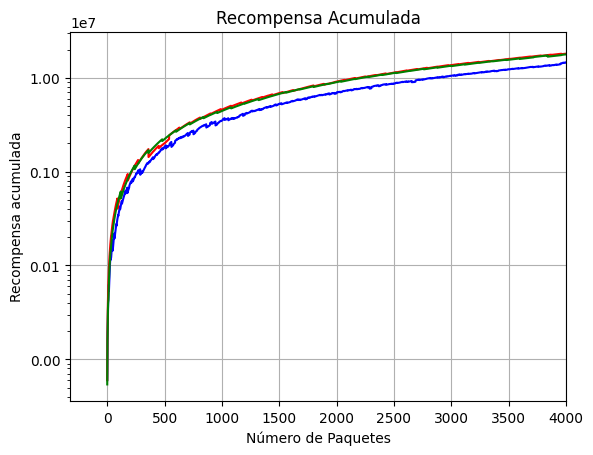

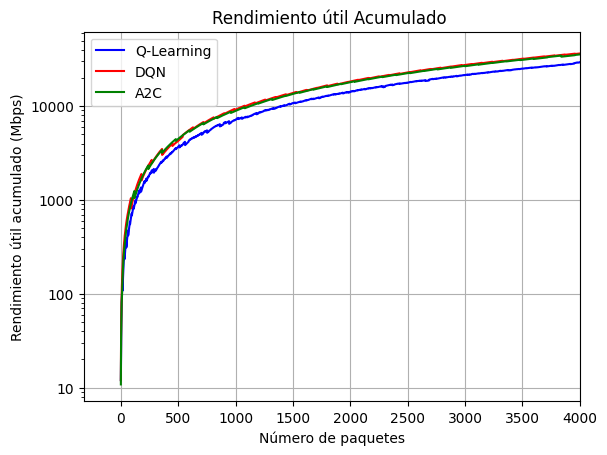

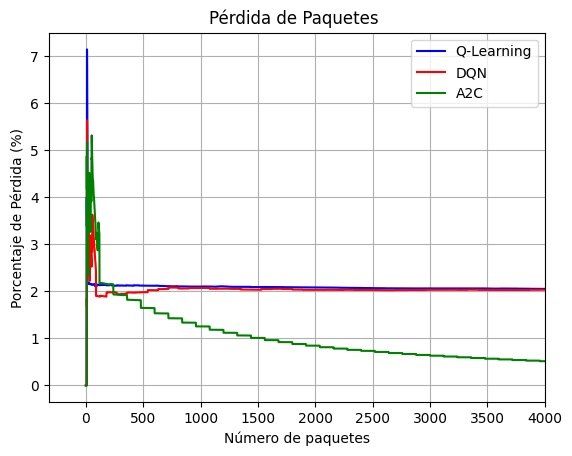

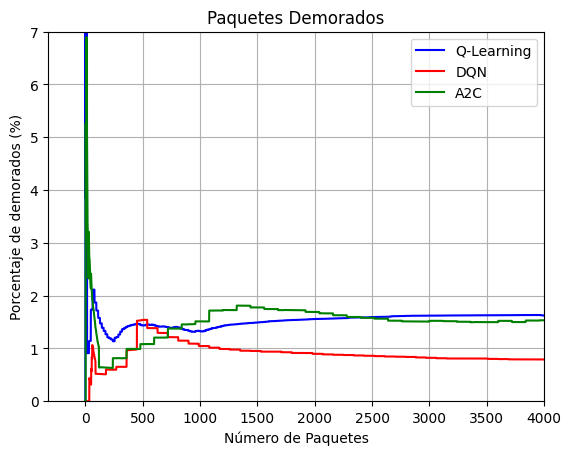

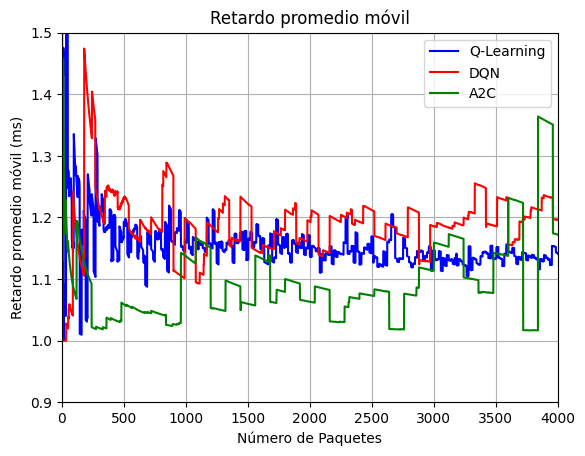

In [ ]:
# Recompensa Acumulada
plt.plot(rewards_ql, label='Q-Learning', color='blue') 
plt.plot(rewards_dqn, label='DQN', color='red')  
plt.plot(rewards_a2c, label='A2C', color='green') 
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter()) 
plt.title('Recompensa Acumulada')
plt.xlabel('Número de Paquetes')
plt.ylabel('Recompensa acumulada')
plt.grid(True)  
plt.xlim(None, 4000) 
plt.show()

# Rendimiento Util Acumulado
plt.plot(goodputs_ql, label='Q-Learning', color='blue')  
plt.plot(goodputs_dqn, label='DQN', color='red')  
plt.plot(goodputs_a2c, label='A2C', color='green')  
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())  
plt.title('Rendimiento útil Acumulado ')
plt.xlabel('Número de paquetes')
plt.ylabel('Rendimiento útil acumulado (Mbps)')
plt.legend()
plt.grid(True)
plt.xlim(None, 4000)  
plt.show()

# Perdida de Paquetes
plt.plot(losses_ql, label='Q-Learning', color='blue')  
plt.plot(losses_dqn, label='DQN', color='red')  
plt.plot(losses_a2c, label='A2C', color='green')   
plt.title('Pérdida de Paquetes ')
plt.xlabel('Número de paquetes')
plt.ylabel('Porcentaje de Pérdida (%)')
plt.legend()  
plt.grid(True)
plt.xlim(None, 4000)  
plt.show()


# Paquetes demorados
plt.plot(delayes_ql, label='Q-Learning', color='blue')  
plt.plot(delayes_dqn, label='DQN', color='red')  
plt.plot(delayes_a2c, label='A2C', color='green')   
plt.title('Paquetes Demorados')
plt.xlabel('Número de Paquetes')
plt.ylabel('Porcentaje de demorados (%)')
plt.legend()  
plt.grid(True)

plt.xlim(None, 4000)  
plt.ylim(0, 7) 
plt.show()

# Retardo Promedio movil
plt.plot(latencies_ql, label='Q-Learning', color='blue')  
plt.plot(latencies_dqn, label='DQN', color='red')  
plt.plot(latencies_a2c, label='A2C', color='green')    
plt.title('Retardo promedio móvil')
plt.xlabel('Número de Paquetes')
plt.ylabel('Retardo promedio móvil (ms)')
plt.legend()  
plt.grid(True)

plt.xlim(0, 4000)  
plt.ylim(0.9, 1.5) 
plt.show()